In [ ]:
from google.colab import drive
import os

# 1. Mount your Google Drive (A prompt will ask for permission)
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from tqdm import tqdm

In [ ]:
# ==============================================================================
# STAGE 1: UNSUPERVISED GEOMETRIC PROXY LABELS GENERATION
# Framework: Two-Stage Cascade Triage (Screening -> Multi-class Staging)
# Author: Rajesh
# ==============================================================================

import os
import glob
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
# ==============================================================================
# 1. DIRECTORY CONFIGURATION & TRACKING SETUP
# ==============================================================================
BASE_DIR = '/content/drive/MyDrive/MTech_Thesis_Dataset/OCDC_Dataset/H&E-stained oral squamous cell carcinoma histological images dataset/training/tumor/patch/640x640'
OUTPUT_CSV = '/content/drive/MyDrive/MTech_Thesis_Dataset/proxy_doi_labels_multi_stage.csv'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
print("--- Step 1: Parsing Data Subdirectories ---")
roi_data = []
non_roi_data = []

patient_folders = [f.path for f in os.scandir(BASE_DIR) if f.is_dir()]

for patient_dir in patient_folders:
    patient_id = os.path.basename(patient_dir)

    # 1. Map ROI (Malignant Tumor Cohort) Elements
    roi_orig_dir = os.path.join(patient_dir, '01-roi', '01-original')
    roi_mask_dir = os.path.join(patient_dir, '01-roi', '02-mask')

    if os.path.exists(roi_orig_dir) and os.path.exists(roi_mask_dir):
        for img_path in glob.glob(os.path.join(roi_orig_dir, '*.*')):
            img_name = os.path.basename(img_path)
            mask_path = os.path.join(roi_mask_dir, img_name)
            if os.path.exists(mask_path):
                roi_data.append({
                    'patient_id': patient_id, 'image_name': img_name,
                    'image_path': img_path, 'mask_path': mask_path, 'type': 'cancer'
                })

    # 2. Map Non-ROI (Healthy Control Baseline Cohort) Elements
    non_roi_orig_dir = os.path.join(patient_dir, '02-non_roi', '01-original')
    non_roi_mask_dir = os.path.join(patient_dir, '02-non_roi', '02-mask')

    if os.path.exists(non_roi_orig_dir) and os.path.exists(non_roi_mask_dir):
        for img_path in glob.glob(os.path.join(non_roi_orig_dir, '*.*')):
            img_name = os.path.basename(img_path)
            mask_path = os.path.join(non_roi_mask_dir, img_name)
            if os.path.exists(mask_path):
                non_roi_data.append({
                    'patient_id': patient_id, 'image_name': img_name,
                    'image_path': img_path, 'mask_path': mask_path, 'type': 'healthy'
                })

print(f"Directory Map Summary: Loaded {len(roi_data)} Cancer images & {len(non_roi_data)} Healthy images.")

--- Step 1: Parsing Data Subdirectories ---
Directory Map Summary: Loaded 390 Cancer images & 450 Healthy images.


In [ ]:
# ==============================================================================
# 2. GLOBALLY AGGREGATED MORPHOLOGY RUN TIME
# ==============================================================================
print("\n--- Step 2: Running Global Border Geometry Extractor ---")

def extract_global_morphology_features(mask):
    # Ensure binary format consistency
    mask_uint8 = (mask > 0).astype(np.uint8)

    # Extract ALL component contours (main mass + independent micro-satellite nests)
    contours, _ = cv2.findContours(
        mask_uint8,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return [0, 0, 0, 0, 0]

    # Feature 1: Satellite Cluster Counting (Quantifies WPOI tumor budding metrics)
    total_clusters = len(contours)

    # Feature 2 & 3: Total Cumulative Metric Integration
    total_area = sum(cv2.contourArea(cnt) for cnt in contours)
    total_perimeter = sum(cv2.arcLength(cnt, True) for cnt in contours)

    if total_perimeter == 0:
        total_perimeter = 1

    # Feature 4: Circularity
    global_circularity = (4 * np.pi * total_area) / (total_perimeter ** 2)

    # Feature 5: Collective Hull Solidity Enclosure
    all_points = np.vstack([cnt for cnt in contours])
    global_hull = cv2.convexHull(all_points)
    global_hull_area = cv2.contourArea(global_hull)

    global_solidity = total_area / global_hull_area if global_hull_area > 0 else 0

    return [
        total_area,
        total_perimeter,
        total_clusters,
        global_circularity,
        global_solidity
    ]

# Execute geometric pipeline strictly on Cancer tissue data rows
features_list = []
for item in tqdm(roi_data, desc="Processing Tumor Morphology"):
    mask = cv2.imread(item['mask_path'], cv2.IMREAD_GRAYSCALE)
    feat = extract_global_morphology_features(mask)
    features_list.append(feat)

features = np.array(features_list)


--- Step 2: Running Global Border Geometry Extractor ---


Processing Tumor Morphology: 100%|██████████| 390/390 [02:19<00:00,  2.80it/s]


In [ ]:
# ==============================================================================
# EXPLICIT MORPHOLOGICAL SEVERITY SCORING (EXPLAINABLE AI)
# ==============================================================================
print("\n--- Step 3: Computing Explicit Morphological Severity Scores ---")

# Extract the individual unscaled metrics from our features matrix
areas              = features[:, 0]
perimeters         = features[:, 1]
detached_clusters  = features[:, 2]
circularities      = features[:, 3]
solidities         = features[:, 4]

# Min-Max Normalization for detached clusters to guarantee a strict [0, 1] range
min_buds = np.min(detached_clusters)
max_buds = np.max(detached_clusters)
normalized_buds = (detached_clusters - min_buds) / (max_buds - min_buds + 1e-6)

# The Corrected Explainable Severity Scoring Equation
severity_scores = (
    0.4 * (1.0 - solidities) +     # Penalty for structural fracturing
    0.3 * (1.0 - circularities) + # Penalty for losing cohesive round shape
    0.3 * normalized_buds          # Penalty for detached tumor budding (WPOI)
)

# Convert the continuous score directly into clean, sorted clinical classes
low_threshold  = np.percentile(severity_scores, 33.3)
high_threshold = np.percentile(severity_scores, 66.6)

# Store these classes temporarily in an array to use for our validation prints
assigned_classes = np.zeros(len(roi_data), dtype=int)

for i, item in enumerate(roi_data):
    score = severity_scores[i]
    item['Severity_Score'] = float(score)

    # Assign clear, perfectly ordered progression tiers
    if score <= low_threshold:
        item['Proxy_DOI_Class'] = 0  # Shallow Severity
        assigned_classes[i] = 0
    elif score <= high_threshold:
        item['Proxy_DOI_Class'] = 1  # Moderate Severity
        assigned_classes[i] = 1
    else:
        item['Proxy_DOI_Class'] = 2  # Deep Severity
        assigned_classes[i] = 2


--- Step 3: Computing Explicit Morphological Severity Scores ---


In [ ]:
# ==============================================================================
# 4. SECURE INTEGRATION & PERMANENT GOOGLE DRIVE SAVE
# ==============================================================================
print("\n--- Step 4: Finalizing Dataset & Saving to Drive ---")

# Isolate healthy controls to a clean absolute baseline category
for item in non_roi_data:
    item['Severity_Score'] = -999.0
    item['Proxy_DOI_Class'] = -1

# Combine elements to single data array list structure
final_dataset = roi_data + non_roi_data
df_final = pd.DataFrame(final_dataset)

# Clean re-assignment for the Cascade Model:
def assign_cascade_labels(row):
    if row['type'] == 'healthy':
        return 0  # Stage 1 Target Class
    else:
        return int(row['Proxy_DOI_Class'] + 1) # Maps 0,1,2 to 1,2,3 for Stage 2

df_final['Proxy_DOI_Class'] = df_final.apply(assign_cascade_labels, axis=1)

# Save file permanently into your Google Drive path destination location
df_final.to_csv(OUTPUT_CSV, index=False)

print(f"\n🌟 Success! Final cascade labels saved to: {OUTPUT_CSV}")
print("\nFinal Cascade Class Distribution for your Thesis Profile:")
print("Class 0 (Healthy Tissue Baseline)      :", len(df_final[df_final['Proxy_DOI_Class'] == 0]))
print("Class 1 (Malignant: Shallow Severity)  :", len(df_final[df_final['Proxy_DOI_Class'] == 1]))
print("Class 2 (Malignant: Moderate Severity) :", len(df_final[df_final['Proxy_DOI_Class'] == 2]))
print("Class 3 (Malignant: Deep Severity)     :", len(df_final[df_final['Proxy_DOI_Class'] == 3]))


--- Step 4: Finalizing Dataset & Saving to Drive ---

🌟 Success! Final cascade labels saved to: /content/drive/MyDrive/MTech_Thesis_Dataset/proxy_doi_labels_multi_stage.csv

Final Cascade Class Distribution for your Thesis Profile:
Class 0 (Healthy Tissue Baseline)      : 450
Class 1 (Malignant: Shallow Severity)  : 130
Class 2 (Malignant: Moderate Severity) : 130
Class 3 (Malignant: Deep Severity)     : 130


In [ ]:
# ==============================================================================
# FIXED CLUSTER VALIDATION & GEOMETRIC TRAIT INSPECTION
# ==============================================================================
print("\n=== MORPHOLOGICAL CLUSTER VALIDATION ===")

# Explicit names mapping directly to your percentile groups
class_names = {
    0: "Class 1: Shallow Severity (Unified Mass, Smooth)",
    1: "Class 2: Moderate Severity (Expanding Core)",
    2: "Class 3: Deep Severity (Highly Fragmented / Budding)"
}

for c in [0, 1, 2]:
    # Find row indices in the features matrix belonging to our formula-assigned class
    idx = np.where(assigned_classes == c)[0]

    print(f"\n{"="*60}")
    print(f" {class_names[c]} ")
    print(f"{"="*60}")
    print(f"Total Patch Count grouped in this tier: {len(idx)}")

    # Average Global Tumor Area
    mean_area = np.mean(features[idx, 0])
    print(f"Average Cumulative Area       : {mean_area:.2f} pixels")

    # Average Global Border Perimeter
    mean_perimeter = np.mean(features[idx, 1])
    print(f"Average Cumulative Perimeter  : {mean_perimeter:.2f} pixels")

    # Average Satellite Component Count / Budding Frequencies
    mean_clusters = np.mean(features[idx, 2])
    print(f"Average Detached Cluster Count: {mean_clusters:.2f} discrete buds")

    # Average Global Circularity
    mean_circularity = np.mean(features[idx, 3])
    print(f"Average Tissue Circularity    : {mean_circularity:.4f} (1.0 = perfect circle)")

    # Average Global Solidity
    mean_solidity = np.mean(features[idx, 4])
    print(f"Average Hull Solidity Enclosure: {mean_solidity:.4f} (Lower = more invasive fracturing)")

print(f"\n{"="*60}\nVerification complete. Use these metrics to validate your pipeline shapes.")


=== MORPHOLOGICAL CLUSTER VALIDATION ===

 Class 1: Shallow Severity (Unified Mass, Smooth) 
Total Patch Count grouped in this tier: 130
Average Cumulative Area       : 191150.91 pixels
Average Cumulative Perimeter  : 2294.63 pixels
Average Detached Cluster Count: 1.30 discrete buds
Average Tissue Circularity    : 0.4483 (1.0 = perfect circle)
Average Hull Solidity Enclosure: 0.8898 (Lower = more invasive fracturing)

 Class 2: Moderate Severity (Expanding Core) 
Total Patch Count grouped in this tier: 130
Average Cumulative Area       : 195232.01 pixels
Average Cumulative Perimeter  : 3919.05 pixels
Average Detached Cluster Count: 2.97 discrete buds
Average Tissue Circularity    : 0.1752 (1.0 = perfect circle)
Average Hull Solidity Enclosure: 0.6489 (Lower = more invasive fracturing)

 Class 3: Deep Severity (Highly Fragmented / Budding) 
Total Patch Count grouped in this tier: 130
Average Cumulative Area       : 127853.60 pixels
Average Cumulative Perimeter  : 4616.69 pixels
Average

In [ ]:
# ==============================================================================
# FIXED VALIDATION: VERIFYING CONTINUOUS SEVERITY SCORE DISTRIBUTION
# ==============================================================================
print("\n=== MORPHOLOGICAL SEVERITY SCORE VERIFICATION ===")

# Loop through our formula-driven metric tiers
for c in [0, 1, 2]:
    # Extract indices belonging to the current proxy class
    idx = np.where(assigned_classes == c)[0]

    # Calculate the mathematical average of your formula's output for this group
    mean_score = np.mean(severity_scores[idx])

    print(f"\n------------------------------------------------------------")
    print(f"{class_names[c]}")
    print(f"------------------------------------------------------------")
    print(f"Total Logged Patches : {len(idx)}")
    print(f"Average Severity Score: {mean_score:.4f}")

print(f"\n------------------------------------------------------------")


=== MORPHOLOGICAL SEVERITY SCORE VERIFICATION ===

------------------------------------------------------------
Class 1: Shallow Severity (Unified Mass, Smooth)
------------------------------------------------------------
Total Logged Patches : 130
Average Severity Score: 0.2135

------------------------------------------------------------
Class 2: Moderate Severity (Expanding Core)
------------------------------------------------------------
Total Logged Patches : 130
Average Severity Score: 0.4135

------------------------------------------------------------
Class 3: Deep Severity (Highly Fragmented / Budding)
------------------------------------------------------------
Total Logged Patches : 130
Average Severity Score: 0.5757

------------------------------------------------------------


In [ ]:
import os
import glob

#BASE_DIR = '/content/drive/MyDrive/patch/640x640'
patient_folders = [f.path for f in os.scandir(BASE_DIR) if f.is_dir()]

total_images_found = 0
missing_masks = []

for patient_dir in patient_folders:
    original_dir = os.path.join(patient_dir, '01-roi', '01-original')
    mask_dir = os.path.join(patient_dir, '01-roi', '02-mask')

    if not os.path.exists(original_dir) or not os.path.exists(mask_dir):
        continue

    img_paths = glob.glob(os.path.join(original_dir, '*.*'))
    total_images_found += len(img_paths)

    for img_path in img_paths:
        img_name = os.path.basename(img_path)
        mask_path = os.path.join(mask_dir, img_name)

        # If the exact match fails, log it
        if not os.path.exists(mask_path):
            missing_masks.append((patient_dir, img_name))

print(f"Total original images found in all folders: {total_images_found}")
print(f"Total images that FAILED to find a mask: {len(missing_masks)}")

if missing_masks:
    print("\n--- Why did they fail? Let's look at the first 3 failures ---")
    for p_dir, name in missing_masks[:3]:
        print(f"Image name: '{name}'")

    print("\n--- What is ACTUALLY inside the mask folder for that first failure? ---")
    failed_mask_dir = os.path.join(missing_masks[0][0], '01-roi', '02-mask')
    if os.path.exists(failed_mask_dir):
        actual_masks = os.listdir(failed_mask_dir)
        print(f"Actual masks found (first 5): {actual_masks[:5]}")

Total original images found in all folders: 390
Total images that FAILED to find a mask: 0


In [ ]:
import os
import glob

#BASE_DIR = '/content/drive/MyDrive/patch/640x640'
patient_folders = [f.path for f in os.scandir(BASE_DIR) if f.is_dir()]

total_images_found = 0
missing_masks = []

for patient_dir in patient_folders:
    original_dir = os.path.join(patient_dir, '02-non_roi', '01-original')
    mask_dir = os.path.join(patient_dir, '02-non_roi', '02-mask')

    if not os.path.exists(original_dir) or not os.path.exists(mask_dir):
        continue

    img_paths = glob.glob(os.path.join(original_dir, '*.*'))
    total_images_found += len(img_paths)

    for img_path in img_paths:
        img_name = os.path.basename(img_path)
        mask_path = os.path.join(mask_dir, img_name)

        # If the exact match fails, log it
        if not os.path.exists(mask_path):
            missing_masks.append((patient_dir, img_name))

print(f"Total original images found in all folders: {total_images_found}")
print(f"Total images that FAILED to find a mask: {len(missing_masks)}")

if missing_masks:
    print("\n--- Why did they fail? Let's look at the first 3 failures ---")
    for p_dir, name in missing_masks[:3]:
        print(f"Image name: '{name}'")

    print("\n--- What is ACTUALLY inside the mask folder for that first failure? ---")
    failed_mask_dir = os.path.join(missing_masks[0][0], '02-non_roi', '02-mask')
    if os.path.exists(failed_mask_dir):
        actual_masks = os.listdir(failed_mask_dir)
        print(f"Actual masks found (first 5): {actual_masks[:5]}")

Total original images found in all folders: 450
Total images that FAILED to find a mask: 0


# **DATA AUGMENTATION WITH WEIGHTED LOSS**

In [ ]:
# ==============================================================================
# MASTER THESIS PIPELINE: IGCA-ViT for OSCC Depth of Invasion
# Author: Rajesh
# Architecture: Interface-Guided Cross-Attention Vision Transformer (Transfer Learning)
# Techniques: Joint Augmentation, Weighted Random Sampling, Weighted Cross-Entropy
# ==============================================================================

import os
import cv2
import random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# ==============================================================================
# PART 1: THE DATASET & JOINT AUGMENTATION
# ==============================================================================
class OSCCProxyDataset(Dataset):
    def __init__(self, csv_file, transform=None, is_train=False):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        self.is_train = is_train

        # Masks must be resized to 224x224 to match ViT tokens, using NEAREST interpolation
        self.mask_transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.ToTensor()
        ])

        # Color Jitter strictly for H&E morphology (never applied to masks)
        self.color_jitter = transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = row['image_path']
        mask_path = row['mask_path']
        label = row['Proxy_DOI_Class']

        # 1. Load Raw Data
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # 2. Extract Masks (Morphological Gradient for the Interface Prior)
        if mask_path == 'NONE':
            h, w = img.shape[:2]
            mask_bulk = np.zeros((h, w), dtype=np.uint8)
            mask_edge = np.zeros((h, w), dtype=np.uint8)
        else:
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            _, mask_bulk = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
            kernel = np.ones((5, 5), np.uint8)
            mask_edge = cv2.morphologyEx(mask_bulk, cv2.MORPH_GRADIENT, kernel)

        # Convert to PIL
        img_pil = Image.fromarray(img)
        mask_bulk_pil = Image.fromarray(mask_bulk)
        mask_edge_pil = Image.fromarray(mask_edge)

        # 3. JOINT DATA AUGMENTATION (Training only)
        if self.is_train:
            if random.random() > 0.5:
                img_pil = TF.hflip(img_pil)
                mask_bulk_pil = TF.hflip(mask_bulk_pil)
                mask_edge_pil = TF.hflip(mask_edge_pil)

            if random.random() > 0.5:
                img_pil = TF.vflip(img_pil)
                mask_bulk_pil = TF.vflip(mask_bulk_pil)
                mask_edge_pil = TF.vflip(mask_edge_pil)

            angles = [0, 90, 180, 270]
            angle = random.choice(angles)
            if angle > 0:
                img_pil = TF.rotate(img_pil, angle)
                mask_bulk_pil = TF.rotate(mask_bulk_pil, angle)
                mask_edge_pil = TF.rotate(mask_edge_pil, angle)

            img_pil = self.color_jitter(img_pil)

        # 4. Final Transforms
        if self.transform:
            img_tensor = self.transform(img_pil)

        mask_bulk_tensor = self.mask_transform(mask_bulk_pil)
        mask_edge_tensor = self.mask_transform(mask_edge_pil)
        label_tensor = torch.tensor(label, dtype=torch.long)

        return img_tensor, mask_bulk_tensor, mask_edge_tensor, label_tensor

In [ ]:
# ==============================================================================
# PART 2: THE NOVEL IGCA-ViT ARCHITECTURE
# ==============================================================================
class IGCABlock(nn.Module):
    """Novel Interface-Guided Cross-Attention Block"""
    def __init__(self, embed_dim=768, num_heads=8):
        super().__init__()
        self.norm_edge = nn.LayerNorm(embed_dim)
        self.norm_bulk = nn.LayerNorm(embed_dim)
        self.cross_attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.ffn = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Linear(embed_dim * 4, embed_dim)
        )

    def forward(self, edge_tokens, bulk_tokens):
        q = self.norm_edge(edge_tokens)
        k = self.norm_bulk(bulk_tokens)
        v = k
        attn_output, _ = self.cross_attn(query=q, key=k, value=v)
        x = edge_tokens + attn_output
        x = x + self.ffn(x)
        return x

class IGCA_ViT_Transfer(nn.Module):
    """Transfer Learning ViT with Frozen Backbone and Custom IGCA Head"""
    def __init__(self, num_classes=3, embed_dim=768):
        super().__init__()
        # Load Frozen Backbone
        self.backbone = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Novel Head
        self.igca_layer = IGCABlock(embed_dim=embed_dim, num_heads=8)
        self.norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def extract_pretrained_tokens(self, x):
        x = self.backbone._process_input(x)
        n = x.shape[0]
        batch_class_token = self.backbone.class_token.expand(n, -1, -1)
        x = torch.cat([batch_class_token, x], dim=1)
        x = self.backbone.encoder(x)
        return x

    def forward(self, img, mask_bulk, mask_edge):
        bulk_img = img * mask_bulk
        edge_img = img * mask_edge

        with torch.no_grad():
            bulk_tokens = self.extract_pretrained_tokens(bulk_img)
            edge_tokens = self.extract_pretrained_tokens(edge_img)

        fused_tokens = self.igca_layer(edge_tokens=edge_tokens, bulk_tokens=bulk_tokens)
        global_feature = fused_tokens[:, 1:, :].mean(dim=1)

        global_feature = self.norm(global_feature)
        logits = self.classifier(global_feature)
        return logits

In [ ]:
# ==============================================================================
# PART 3: DATA PIPELINE SETUP & SAMPLER
# ==============================================================================
print("Setting up Data Pipeline...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- UPDATE THIS PATH TO YOUR ACTUAL CSV ---
csv_path = '/content/drive/MyDrive/MTech_Thesis_Dataset/proxy_doi_labels.csv'

vit_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

base_dataset = OSCCProxyDataset(csv_file=csv_path, transform=vit_transforms)
total_size = len(base_dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(base_dataset, [train_size, val_size], generator=generator)

# Turn ON augmentation for training, OFF for validation
train_dataset.dataset.is_train = True
val_dataset.dataset.is_train = False

# Oversampling the minority classes
train_labels = [train_dataset.dataset.data.iloc[idx]['Proxy_DOI_Class'] for idx in train_dataset.indices]
class_weights_dict = {0: 0.62, 1: 1.43, 2: 1.43}
sample_weights = [class_weights_dict[label] for label in train_labels]

sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)

print(f"Pipeline Ready: {train_size} Train Images | {val_size} Val Images")

Setting up Data Pipeline...
Pipeline Ready: 672 Train Images | 168 Val Images


In [ ]:
# ==============================================================================
# PART 4: TRAINING LOOP WITH CHECKPOINTING
# ==============================================================================
model = IGCA_ViT_Transfer(num_classes=3).to(device)

# Weighted Loss Function
loss_weights = torch.tensor([0.62, 1.43, 1.43], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=loss_weights)

# Optimizer strictly for custom head
trainable_params = filter(lambda p: p.requires_grad, model.parameters())
optimizer = optim.AdamW(trainable_params, lr=1e-4, weight_decay=1e-3)

EPOCHS = 20
best_val_loss = float('inf')
save_path = '/content/drive/MyDrive/MTech_Thesis_Dataset/IGCA_ViT_Best_Weights.pth'

print(f"\n--- Starting IGCA-ViT Training on {device} ---")
for epoch in range(EPOCHS):

    # --- TRAINING PHASE ---
    model.train()
    train_loss, train_correct = 0.0, 0
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")

    for imgs, bulk_masks, edge_masks, labels in train_loop:
        imgs, bulk_masks, edge_masks, labels = imgs.to(device), bulk_masks.to(device), edge_masks.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs, bulk_masks, edge_masks)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_correct += torch.sum(preds == labels.data).item()
        train_loop.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = train_correct / train_size

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss, val_correct = 0.0, 0

    with torch.no_grad():
        val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Valid]")
        for imgs, bulk_masks, edge_masks, labels in val_loop:
            imgs, bulk_masks, edge_masks, labels = imgs.to(device), bulk_masks.to(device), edge_masks.to(device), labels.to(device)

            outputs = model(imgs, bulk_masks, edge_masks)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data).item()

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = val_correct / val_size

    print(f"\nEnd of Epoch {epoch+1}")
    print(f"TRAIN -> Loss: {avg_train_loss:.4f} | Acc: {avg_train_acc:.4f}")
    print(f"VALID -> Loss: {avg_val_loss:.4f} | Acc: {avg_val_acc:.4f}")

    # --- MODEL CHECKPOINTING ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), save_path)
        print(f"🌟 Validation Loss Improved! Model Saved to Drive.")
    else:
        print("Validation Loss did not improve.")
    print("-" * 50)


--- Starting IGCA-ViT Training on cuda ---


Epoch 1/20 [Valid]: 100%|██████████| 11/11 [00:08<00:00,  1.30it/s]



End of Epoch 1
TRAIN -> Loss: 0.4548 | Acc: 0.8080
VALID -> Loss: 0.2928 | Acc: 0.9107
🌟 Validation Loss Improved! Model Saved to Drive.
--------------------------------------------------


Epoch 2/20 [Valid]: 100%|██████████| 11/11 [00:08<00:00,  1.29it/s]



End of Epoch 2
TRAIN -> Loss: 0.3067 | Acc: 0.8824
VALID -> Loss: 0.3632 | Acc: 0.8750
Validation Loss did not improve.
--------------------------------------------------


...


End of Epoch 18
TRAIN -> Loss: 0.0024 | Acc: 1.0000
VALID -> Loss: 0.5542 | Acc: 0.9167
Validation Loss did not improve.
--------------------------------------------------


Epoch 19/20 [Valid]: 100%|██████████| 11/11 [00:08<00:00,  1.34it/s]



End of Epoch 19
TRAIN -> Loss: 0.0037 | Acc: 0.9985
VALID -> Loss: 0.6033 | Acc: 0.8988
Validation Loss did not improve.
--------------------------------------------------


Epoch 20/20 [Valid]: 100%|██████████| 11/11 [00:06<00:00,  1.64it/s]


End of Epoch 20
TRAIN -> Loss: 0.0025 | Acc: 0.9985
VALID -> Loss: 0.5686 | Acc: 0.8988
Validation Loss did not improve.
--------------------------------------------------



--- Running Final Evaluation on Best Model ---

=== CLASSIFICATION REPORT ===
                           precision    recall  f1-score   support

Class 0 (Healthy/Shallow)       1.00      0.92      0.96       105
       Class 1 (Moderate)       0.61      0.77      0.68        22
           Class 2 (Deep)       0.88      0.93      0.90        41

                 accuracy                           0.90       168
                macro avg       0.83      0.87      0.85       168
             weighted avg       0.92      0.90      0.91       168


=== GENERATING CONFUSION MATRIX ===


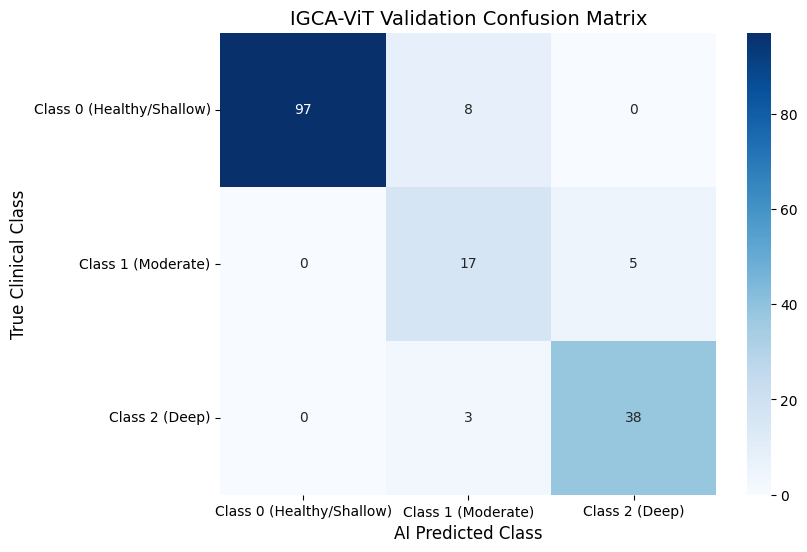

In [ ]:
# ==============================================================================
# PART 5: FINAL EVALUATION ON BEST WEIGHTS
# ==============================================================================
print("\n--- Running Final Evaluation on Best Model ---")
eval_model = IGCA_ViT_Transfer(num_classes=3).to(device)
eval_model.load_state_dict(torch.load(save_path, map_location=device))
eval_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, bulk_masks, edge_masks, labels in val_loader:
        imgs, bulk_masks, edge_masks = imgs.to(device), bulk_masks.to(device), edge_masks.to(device)
        outputs = eval_model(imgs, bulk_masks, edge_masks)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n=== CLASSIFICATION REPORT ===")
target_names = ['Class 0 (Healthy/Shallow)', 'Class 1 (Moderate)', 'Class 2 (Deep)']
print(classification_report(all_labels, all_preds, target_names=target_names))

print("\n=== GENERATING CONFUSION MATRIX ===")
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('IGCA-ViT Validation Confusion Matrix', fontsize=14)
plt.ylabel('True Clinical Class', fontsize=12)
plt.xlabel('AI Predicted Class', fontsize=12)
plt.show()



1. HAVE TO DO WITHOUT AUGMENTATION BY SAVING THE BEST MODEL.
2. ALSO DO WITHOUT WEIGHTED LOSS
3. ALSO TEST ALL THREE MODELS ON YOUR TEST DATA
4. ALSO INTEGRATE METADATA
5. START SEARCHING FOR COMPARISON MODEL



# **WITHOUT DATA AUGMENTATION**

In [ ]:
import cv2
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image

class OSCCProxyDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        """
        Custom Dataset for the IGCA-ViT.
        Loads the H&E image, the solid bulk mask, and dynamically extracts the edge mask.
        """
        self.data = pd.read_csv(csv_file)
        self.transform = transform

        # --- THE FIX: Added a Resize step specifically for the masks ---
        self.mask_transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = row['image_path']
        mask_path = row['mask_path']
        label = row['Proxy_DOI_Class']

        # 1. Load the raw H&E Image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # 2. Handle Masks (Cancer vs. Healthy)
        if mask_path == 'NONE':
            # Healthy tissue: Create blank masks (all zeros)
            h, w = img.shape[:2]
            mask_bulk = np.zeros((h, w), dtype=np.uint8)
            mask_edge = np.zeros((h, w), dtype=np.uint8)
        else:
            # Cancer tissue: Load mask and extract the edge
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            _, mask_bulk = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

            # The Morphological Gradient mathematically isolates the tumor boundary
            # A 5x5 kernel creates a sufficiently thick boundary for the ViT patches
            kernel = np.ones((5, 5), np.uint8)
            mask_edge = cv2.morphologyEx(mask_bulk, cv2.MORPH_GRADIENT, kernel)

        # 3. Convert to PIL Images for Torchvision compatibility
        img_pil = Image.fromarray(img)
        mask_bulk_pil = Image.fromarray(mask_bulk)
        mask_edge_pil = Image.fromarray(mask_edge)

        # 4. Apply Transforms (Resizing, Normalizing, etc.)
        if self.transform:
            img_tensor = self.transform(img_pil)

        # Masks only need to be converted to [0, 1] tensors, never normalized
        mask_bulk_tensor = self.mask_transform(mask_bulk_pil)
        mask_edge_tensor = self.mask_transform(mask_edge_pil)

        label_tensor = torch.tensor(label, dtype=torch.long)

        return img_tensor, mask_bulk_tensor, mask_edge_tensor, label_tensor

# ==========================================
# HOW TO USE IT IN YOUR NOTEBOOK
# ==========================================
if __name__ == "__main__":
    # Define standard ViT image transformations
    vit_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Instantiate the dataset using the CSV we generated in the last step
    csv_path = '/content/drive/MyDrive/MTech_Thesis_Dataset/proxy_doi_labels.csv'
    dataset = OSCCProxyDataset(csv_file=csv_path, transform=vit_transforms)

    # Create the DataLoader for batching
    dataloader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=2)

    # Test the loader to ensure our tensor shapes are correct
    imgs, bulk_masks, edge_masks, labels = next(iter(dataloader))

    print("--- DataLoader Successfully Configured ---")
    print(f"Image Batch Shape:      {imgs.shape} (Batch, Channels, Height, Width)")
    print(f"Bulk Mask Batch Shape:  {bulk_masks.shape}")
    print(f"Edge Mask Batch Shape:  {edge_masks.shape}")
    print(f"Labels Batch Shape:     {labels.shape}")

--- DataLoader Successfully Configured ---
Image Batch Shape:      torch.Size([16, 3, 224, 224]) (Batch, Channels, Height, Width)
Bulk Mask Batch Shape:  torch.Size([16, 1, 224, 224])
Edge Mask Batch Shape:  torch.Size([16, 1, 224, 224])
Labels Batch Shape:     torch.Size([16])


In [ ]:
import torch
import torch.nn as nn

class PatchEmbedding(nn.Module):
    """
    Standard ViT Patch Embedding Layer.
    Converts a 2D image into a 1D sequence of learnable patch tokens.
    """
    def __init__(self, in_channels=3, patch_size=16, embed_dim=256, img_size=224):
        super().__init__()
        self.patch_size = patch_size
        # Using a Conv2d layer with stride=patch_size is the standard way to extract non-overlapping patches
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

        # Calculate how many patches we will have (e.g., 224/16 = 14. 14*14 = 196 patches)
        self.num_patches = (img_size // patch_size) ** 2
        # Learnable positional embeddings to tell the network where each patch came from
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, embed_dim))

    def forward(self, x):
        # x shape: (Batch, Channels, Height, Width)
        x = self.proj(x)  # Shape: (Batch, Embed_Dim, H/patch, W/patch)
        x = x.flatten(2)  # Shape: (Batch, Embed_Dim, Num_Patches)
        x = x.transpose(1, 2)  # Shape: (Batch, Num_Patches, Embed_Dim)
        x = x + self.pos_embed # Add spatial awareness
        return x

class IGCABlock(nn.Module):
    """
    The Novel Interface-Guided Cross-Attention Block.
    Forces the network to evaluate the Bulk tissue strictly from the perspective of the Invasive Edge.
    """
    def __init__(self, embed_dim=256, num_heads=8):
        super().__init__()
        self.norm_edge = nn.LayerNorm(embed_dim)
        self.norm_bulk = nn.LayerNorm(embed_dim)

        # PyTorch's native MultiheadAttention handles the complex Q, K, V math
        self.cross_attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)

        # Standard Feed Forward Network (FFN) to process the attention output
        self.ffn = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Linear(embed_dim * 4, embed_dim)
        )

    def forward(self, edge_tokens, bulk_tokens):
        # 1. Normalize the inputs
        q = self.norm_edge(edge_tokens)
        k = self.norm_bulk(bulk_tokens)
        v = k # Value is usually identical to Key in standard attention

        # 2. CROSS-ATTENTION: Query comes from the Edge. Key/Value come from the Bulk.
        attn_output, _ = self.cross_attn(query=q, key=k, value=v)

        # 3. Residual connection + FFN
        x = edge_tokens + attn_output
        x = x + self.ffn(x)
        return x

class IGCA_ViT(nn.Module):
    """
    The Full Master's Thesis Model.
    Combines Patch Embedding, Cross-Attention, and the Final Classification Head.
    """
    def __init__(self, num_classes=3, embed_dim=256):
        super().__init__()
        self.patch_embed = PatchEmbedding(in_channels=3, embed_dim=embed_dim)

        # A single Cross-Attention block (you can stack more if you want a deeper network)
        self.igca_layer = IGCABlock(embed_dim=embed_dim, num_heads=8)

        # Final classification head
        self.norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, img, mask_bulk, mask_edge):
        # 1. Multiply the raw image by the masks to isolate the tissues
        # img shape: (B, 3, H, W), mask shape: (B, 1, H, W)
        bulk_img = img * mask_bulk
        edge_img = img * mask_edge

        # 2. Convert masked images into sequences of ViT tokens
        bulk_tokens = self.patch_embed(bulk_img)
        edge_tokens = self.patch_embed(edge_img)

        # 3. Pass through the Novel Cross-Attention Layer
        fused_tokens = self.igca_layer(edge_tokens=edge_tokens, bulk_tokens=bulk_tokens)

        # 4. Global Average Pooling: Average all 196 patch tokens into a single summary vector
        global_feature = fused_tokens.mean(dim=1)

        # 5. Classify into 3 proxy DOI classes
        global_feature = self.norm(global_feature)
        logits = self.classifier(global_feature)

        return logits

# ==========================================
# QUICK TEST TO ENSURE IT WORKS
# ==========================================
if __name__ == "__main__":
    model = IGCA_ViT(num_classes=3)

    # Create fake dummy tensors mimicking a batch of 4 images
    dummy_img = torch.randn(4, 3, 224, 224)
    dummy_mask_bulk = torch.ones(4, 1, 224, 224) # 1 channel mask
    dummy_mask_edge = torch.ones(4, 1, 224, 224)

    # Run a forward pass
    output = model(dummy_img, dummy_mask_bulk, dummy_mask_edge)

    print("--- Model Instantiated Successfully ---")
    print(f"Output Shape: {output.shape} (Batch_size, Num_Classes)")
    print("If you see [4, 3] above, your novel architecture is mathematically sound and ready to train!")

--- Model Instantiated Successfully ---
Output Shape: torch.Size([4, 3]) (Batch_size, Num_Classes)
If you see [4, 3] above, your novel architecture is mathematically sound and ready to train!


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

class IGCABlock(nn.Module):
    """
    Your novel Interface-Guided Cross-Attention Block.
    (This remains exactly the same, but now accepts 768-dim tokens from the pre-trained ViT)
    """
    def __init__(self, embed_dim=768, num_heads=8):
        super().__init__()
        self.norm_edge = nn.LayerNorm(embed_dim)
        self.norm_bulk = nn.LayerNorm(embed_dim)
        self.cross_attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.ffn = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Linear(embed_dim * 4, embed_dim)
        )

    def forward(self, edge_tokens, bulk_tokens):
        q = self.norm_edge(edge_tokens)
        k = self.norm_bulk(bulk_tokens)
        v = k
        attn_output, _ = self.cross_attn(query=q, key=k, value=v)
        x = edge_tokens + attn_output
        x = x + self.ffn(x)
        return x

class IGCA_ViT_Transfer(nn.Module):
    """
    The Corrected Master's Thesis Model.
    Uses a Frozen Pre-trained ViT Backbone + Custom IGCA Head.
    """
    def __init__(self, num_classes=3, embed_dim=768):
        super().__init__()

        # 1. Load the Pre-trained ViT (Trained on 14 Million Images)
        self.backbone = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

        # 2. Freeze the backbone so we don't overfit on 840 images
        for param in self.backbone.parameters():
            param.requires_grad = False

        # 3. Your Novel Cross-Attention Layer (Trainable)
        self.igca_layer = IGCABlock(embed_dim=embed_dim, num_heads=8)

        # 4. Final Classification Head (Trainable)
        self.norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def extract_pretrained_tokens(self, x):
        """Helper function to pull the 197 patch tokens out of the torchvision ViT"""
        x = self.backbone._process_input(x)
        n = x.shape[0]
        batch_class_token = self.backbone.class_token.expand(n, -1, -1)
        x = torch.cat([batch_class_token, x], dim=1)
        x = self.backbone.encoder(x)
        return x # Returns sequence of tokens: Shape (Batch, 197, 768)

    def forward(self, img, mask_bulk, mask_edge):
        # 1. Multiply the raw image by the masks
        bulk_img = img * mask_bulk
        edge_img = img * mask_edge

        # 2. Extract highly intelligent features using the FROZEN backbone
        with torch.no_grad(): # Ensure absolutely no gradients are tracked here
            bulk_tokens = self.extract_pretrained_tokens(bulk_img)
            edge_tokens = self.extract_pretrained_tokens(edge_img)

        # 3. Pass through the Novel Cross-Attention Layer (This is what actually learns!)
        fused_tokens = self.igca_layer(edge_tokens=edge_tokens, bulk_tokens=bulk_tokens)

        # 4. Global Average Pooling (Ignore the class token at index 0, average the rest)
        global_feature = fused_tokens[:, 1:, :].mean(dim=1)

        # 5. Classify
        global_feature = self.norm(global_feature)
        logits = self.classifier(global_feature)

        return logits

# ==========================================
# TEST BLOCK
# ==========================================
if __name__ == "__main__":
    model = IGCA_ViT_Transfer(num_classes=3)

    dummy_img = torch.randn(4, 3, 224, 224)
    dummy_mask_bulk = torch.ones(4, 1, 224, 224)
    dummy_mask_edge = torch.ones(4, 1, 224, 224)

    output = model(dummy_img, dummy_mask_bulk, dummy_mask_edge)
    print("--- Transfer Learning Model Instantiated Successfully ---")
    print(f"Output Shape: {output.shape} (Batch_size, Num_Classes)")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:05<00:00, 66.1MB/s]


--- Transfer Learning Model Instantiated Successfully ---
Output Shape: torch.Size([4, 3]) (Batch_size, Num_Classes)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import random_split, DataLoader
from tqdm import tqdm

# ==========================================
# 1. THE TRAIN / VALIDATION SPLIT
# ==========================================
# Assuming 'dataset' is your OSCCProxyDataset instantiated earlier
total_size = len(dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

# Create a fixed generator so the split is identical every single time
fixed_generator = torch.Generator().manual_seed(42)

# Randomly split the data using the fixed seed
train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=fixed_generator)

# Create TWO DataLoaders now
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)

print(f"Data Split Complete: {train_size} Training Images | {val_size} Validation Images")

# ==========================================
# 2. MODEL INITIALIZATION
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = IGCA_ViT_Transfer(num_classes=3).to(device)

# 1. Define the calculated weights mathematically
# Order must match your classes: [Class 0, Class 1, Class 2]
class_weights = torch.tensor([0.62, 1.43, 1.43], dtype=torch.float32).to(device)

# 2. Inject the weights into the Loss Function
criterion = nn.CrossEntropyLoss(weight=class_weights)
trainable_params = filter(lambda p: p.requires_grad, model.parameters())
# Adding slightly higher weight_decay to aggressively penalize memorization
optimizer = optim.AdamW(trainable_params, lr=1e-4, weight_decay=1e-3)

EPOCHS = 20
best_val_loss = float('inf')
save_path = '/content/drive/MyDrive/MTech_Thesis_Dataset/Without_Aug_IGCA_ViT_Best_Weights.pth'

# ==========================================
# 3. THE DUAL-PHASE TRAINING LOOP
# ==========================================
print("\n--- Starting Train/Val Loop ---")

for epoch in range(EPOCHS):

    # -------------------------------
    # PHASE 1: TRAINING
    # -------------------------------
    model.train()
    train_loss = 0.0
    train_correct = 0

    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")

    for imgs, bulk_masks, edge_masks, labels in train_loop:
        imgs, bulk_masks, edge_masks, labels = imgs.to(device), bulk_masks.to(device), edge_masks.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs, bulk_masks, edge_masks)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_correct += torch.sum(preds == labels.data).item()

        train_loop.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = train_correct / train_size

    # -------------------------------
    # PHASE 2: VALIDATION (THE TRUTH)
    # -------------------------------
    model.eval() # Turn off learning!
    val_loss = 0.0
    val_correct = 0

    # We use torch.no_grad() to save massive amounts of RAM during testing
    with torch.no_grad():
        val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Valid]")
        for imgs, bulk_masks, edge_masks, labels in val_loop:
            imgs, bulk_masks, edge_masks, labels = imgs.to(device), bulk_masks.to(device), edge_masks.to(device), labels.to(device)

            outputs = model(imgs, bulk_masks, edge_masks)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data).item()

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = val_correct / val_size

    # -------------------------------
    # EPOCH SUMMARY
    # -------------------------------
    print(f"\nEnd of Epoch {epoch+1}")
    print(f"TRAIN -> Loss: {avg_train_loss:.4f} | Acc: {avg_train_acc:.4f}")
    print(f"VALID -> Loss: {avg_val_loss:.4f} | Acc: {avg_val_acc:.4f}\n")

    # --- MODEL CHECKPOINTING ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), save_path)
        print(f"🌟 Validation Loss Improved! Model Saved to Drive.")
    else:
        print("Validation Loss did not improve.")
    print("-" * 50)

print("--- Training Complete! ---")

Data Split Complete: 672 Training Images | 168 Validation Images

--- Starting Train/Val Loop ---


Epoch 1/20 [Valid]: 100%|██████████| 11/11 [01:36<00:00,  8.75s/it]



End of Epoch 1
TRAIN -> Loss: 0.5015 | Acc: 0.8199
VALID -> Loss: 0.4150 | Acc: 0.8571

🌟 Validation Loss Improved! Model Saved to Drive.
--------------------------------------------------


Epoch 2/20 [Valid]: 100%|██████████| 11/11 [00:06<00:00,  1.58it/s]



End of Epoch 2
TRAIN -> Loss: 0.3588 | Acc: 0.8765
VALID -> Loss: 0.2722 | Acc: 0.9048

🌟 Validation Loss Improved! Model Saved to Drive.
--------------------------------------------------


...


End of Epoch 18
TRAIN -> Loss: 0.0008 | Acc: 1.0000
VALID -> Loss: 0.4942 | Acc: 0.9345

Validation Loss did not improve.
--------------------------------------------------


Epoch 19/20 [Valid]: 100%|██████████| 11/11 [00:08<00:00,  1.27it/s]



End of Epoch 19
TRAIN -> Loss: 0.0006 | Acc: 1.0000
VALID -> Loss: 0.5145 | Acc: 0.9286

Validation Loss did not improve.
--------------------------------------------------


Epoch 20/20 [Valid]: 100%|██████████| 11/11 [00:07<00:00,  1.52it/s]


End of Epoch 20
TRAIN -> Loss: 0.0005 | Acc: 1.0000
VALID -> Loss: 0.5117 | Acc: 0.9345

Validation Loss did not improve.
--------------------------------------------------
--- Training Complete! ---



--- Running Final Evaluation on Best Model ---

=== CLASSIFICATION REPORT ===
                           precision    recall  f1-score   support

Class 0 (Healthy/Shallow)       0.98      0.97      0.98       105
       Class 1 (Moderate)       0.74      0.77      0.76        22
           Class 2 (Deep)       0.93      0.93      0.93        41

                 accuracy                           0.93       168
                macro avg       0.88      0.89      0.89       168
             weighted avg       0.94      0.93      0.94       168


=== GENERATING CONFUSION MATRIX ===


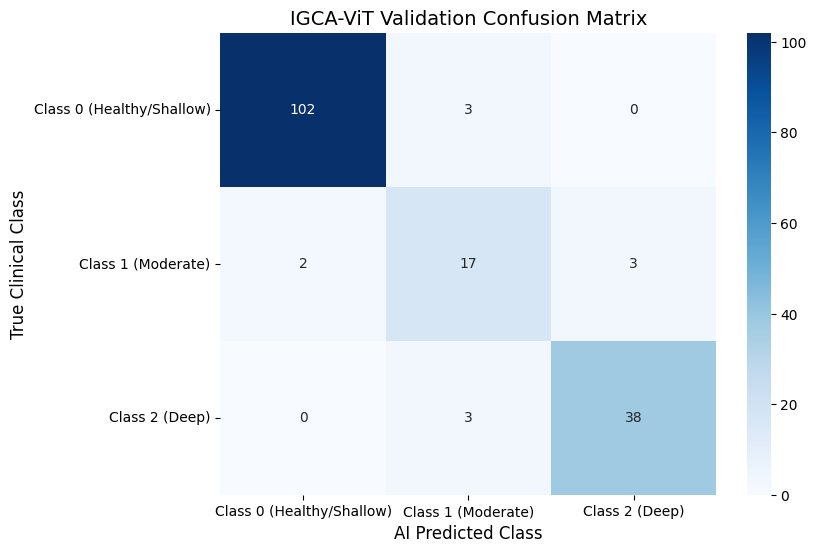

In [ ]:
# ==============================================================================
# MASTER THESIS PIPELINE: IGCA-ViT for OSCC Depth of Invasion
# Author: Rajesh
# Architecture: Interface-Guided Cross-Attention Vision Transformer (Transfer Learning)
# Techniques: Joint Augmentation, Weighted Random Sampling, Weighted Cross-Entropy
# ==============================================================================

import os
import cv2
import random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from sklearn.metrics import classification_report, confusion_matrix

# ==============================================================================
# PART 5: FINAL EVALUATION ON BEST WEIGHTS
# ==============================================================================
print("\n--- Running Final Evaluation on Best Model ---")
eval_model = IGCA_ViT_Transfer(num_classes=3).to(device)
eval_model.load_state_dict(torch.load('/content/drive/MyDrive/MTech_Thesis_Dataset/Without_Aug_IGCA_ViT_Best_Weights.pth', map_location=device))
eval_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, bulk_masks, edge_masks, labels in val_loader:
        imgs, bulk_masks, edge_masks = imgs.to(device), bulk_masks.to(device), edge_masks.to(device)
        outputs = eval_model(imgs, bulk_masks, edge_masks)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n=== CLASSIFICATION REPORT ===")
target_names = ['Class 0 (Healthy/Shallow)', 'Class 1 (Moderate)', 'Class 2 (Deep)']
print(classification_report(all_labels, all_preds, target_names=target_names))

print("\n=== GENERATING CONFUSION MATRIX ===")
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('IGCA-ViT Validation Confusion Matrix', fontsize=14)
plt.ylabel('True Clinical Class', fontsize=12)
plt.xlabel('AI Predicted Class', fontsize=12)
plt.show()

# **WITHOUT WEIGHTED LOSS AND AUGMENTATION**

In [ ]:
import cv2
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image

class OSCCProxyDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        """
        Custom Dataset for the IGCA-ViT.
        Loads the H&E image, the solid bulk mask, and dynamically extracts the edge mask.
        """
        self.data = pd.read_csv(csv_file)
        self.transform = transform

        # --- THE FIX: Added a Resize step specifically for the masks ---
        self.mask_transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = row['image_path']
        mask_path = row['mask_path']
        label = row['Proxy_DOI_Class']

        # 1. Load the raw H&E Image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # 2. Handle Masks (Cancer vs. Healthy)
        if mask_path == 'NONE':
            # Healthy tissue: Create blank masks (all zeros)
            h, w = img.shape[:2]
            mask_bulk = np.zeros((h, w), dtype=np.uint8)
            mask_edge = np.zeros((h, w), dtype=np.uint8)
        else:
            # Cancer tissue: Load mask and extract the edge
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            _, mask_bulk = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

            # The Morphological Gradient mathematically isolates the tumor boundary
            # A 5x5 kernel creates a sufficiently thick boundary for the ViT patches
            kernel = np.ones((5, 5), np.uint8)
            mask_edge = cv2.morphologyEx(mask_bulk, cv2.MORPH_GRADIENT, kernel)

        # 3. Convert to PIL Images for Torchvision compatibility
        img_pil = Image.fromarray(img)
        mask_bulk_pil = Image.fromarray(mask_bulk)
        mask_edge_pil = Image.fromarray(mask_edge)

        # 4. Apply Transforms (Resizing, Normalizing, etc.)
        if self.transform:
            img_tensor = self.transform(img_pil)

        # Masks only need to be converted to [0, 1] tensors, never normalized
        mask_bulk_tensor = self.mask_transform(mask_bulk_pil)
        mask_edge_tensor = self.mask_transform(mask_edge_pil)

        label_tensor = torch.tensor(label, dtype=torch.long)

        return img_tensor, mask_bulk_tensor, mask_edge_tensor, label_tensor

# ==========================================
# HOW TO USE IT IN YOUR NOTEBOOK
# ==========================================
if __name__ == "__main__":
    # Define standard ViT image transformations
    vit_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Instantiate the dataset using the CSV we generated in the last step
    csv_path = '/content/drive/MyDrive/MTech_Thesis_Dataset/proxy_doi_labels.csv'
    dataset = OSCCProxyDataset(csv_file=csv_path, transform=vit_transforms)

    # Create the DataLoader for batching
    dataloader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=2)

    # Test the loader to ensure our tensor shapes are correct
    imgs, bulk_masks, edge_masks, labels = next(iter(dataloader))

    print("--- DataLoader Successfully Configured ---")
    print(f"Image Batch Shape:      {imgs.shape} (Batch, Channels, Height, Width)")
    print(f"Bulk Mask Batch Shape:  {bulk_masks.shape}")
    print(f"Edge Mask Batch Shape:  {edge_masks.shape}")
    print(f"Labels Batch Shape:     {labels.shape}")

--- DataLoader Successfully Configured ---
Image Batch Shape:      torch.Size([16, 3, 224, 224]) (Batch, Channels, Height, Width)
Bulk Mask Batch Shape:  torch.Size([16, 1, 224, 224])
Edge Mask Batch Shape:  torch.Size([16, 1, 224, 224])
Labels Batch Shape:     torch.Size([16])


In [ ]:
import torch
import torch.nn as nn

class PatchEmbedding(nn.Module):
    """
    Standard ViT Patch Embedding Layer.
    Converts a 2D image into a 1D sequence of learnable patch tokens.
    """
    def __init__(self, in_channels=3, patch_size=16, embed_dim=256, img_size=224):
        super().__init__()
        self.patch_size = patch_size
        # Using a Conv2d layer with stride=patch_size is the standard way to extract non-overlapping patches
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

        # Calculate how many patches we will have (e.g., 224/16 = 14. 14*14 = 196 patches)
        self.num_patches = (img_size // patch_size) ** 2
        # Learnable positional embeddings to tell the network where each patch came from
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, embed_dim))

    def forward(self, x):
        # x shape: (Batch, Channels, Height, Width)
        x = self.proj(x)  # Shape: (Batch, Embed_Dim, H/patch, W/patch)
        x = x.flatten(2)  # Shape: (Batch, Embed_Dim, Num_Patches)
        x = x.transpose(1, 2)  # Shape: (Batch, Num_Patches, Embed_Dim)
        x = x + self.pos_embed # Add spatial awareness
        return x

class IGCABlock(nn.Module):
    """
    The Novel Interface-Guided Cross-Attention Block.
    Forces the network to evaluate the Bulk tissue strictly from the perspective of the Invasive Edge.
    """
    def __init__(self, embed_dim=256, num_heads=8):
        super().__init__()
        self.norm_edge = nn.LayerNorm(embed_dim)
        self.norm_bulk = nn.LayerNorm(embed_dim)

        # PyTorch's native MultiheadAttention handles the complex Q, K, V math
        self.cross_attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)

        # Standard Feed Forward Network (FFN) to process the attention output
        self.ffn = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Linear(embed_dim * 4, embed_dim)
        )

    def forward(self, edge_tokens, bulk_tokens):
        # 1. Normalize the inputs
        q = self.norm_edge(edge_tokens)
        k = self.norm_bulk(bulk_tokens)
        v = k # Value is usually identical to Key in standard attention

        # 2. CROSS-ATTENTION: Query comes from the Edge. Key/Value come from the Bulk.
        attn_output, _ = self.cross_attn(query=q, key=k, value=v)

        # 3. Residual connection + FFN
        x = edge_tokens + attn_output
        x = x + self.ffn(x)
        return x

class IGCA_ViT(nn.Module):
    """
    The Full Master's Thesis Model.
    Combines Patch Embedding, Cross-Attention, and the Final Classification Head.
    """
    def __init__(self, num_classes=3, embed_dim=256):
        super().__init__()
        self.patch_embed = PatchEmbedding(in_channels=3, embed_dim=embed_dim)

        # A single Cross-Attention block (you can stack more if you want a deeper network)
        self.igca_layer = IGCABlock(embed_dim=embed_dim, num_heads=8)

        # Final classification head
        self.norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, img, mask_bulk, mask_edge):
        # 1. Multiply the raw image by the masks to isolate the tissues
        # img shape: (B, 3, H, W), mask shape: (B, 1, H, W)
        bulk_img = img * mask_bulk
        edge_img = img * mask_edge

        # 2. Convert masked images into sequences of ViT tokens
        bulk_tokens = self.patch_embed(bulk_img)
        edge_tokens = self.patch_embed(edge_img)

        # 3. Pass through the Novel Cross-Attention Layer
        fused_tokens = self.igca_layer(edge_tokens=edge_tokens, bulk_tokens=bulk_tokens)

        # 4. Global Average Pooling: Average all 196 patch tokens into a single summary vector
        global_feature = fused_tokens.mean(dim=1)

        # 5. Classify into 3 proxy DOI classes
        global_feature = self.norm(global_feature)
        logits = self.classifier(global_feature)

        return logits

# ==========================================
# QUICK TEST TO ENSURE IT WORKS
# ==========================================
if __name__ == "__main__":
    model = IGCA_ViT(num_classes=3)

    # Create fake dummy tensors mimicking a batch of 4 images
    dummy_img = torch.randn(4, 3, 224, 224)
    dummy_mask_bulk = torch.ones(4, 1, 224, 224) # 1 channel mask
    dummy_mask_edge = torch.ones(4, 1, 224, 224)

    # Run a forward pass
    output = model(dummy_img, dummy_mask_bulk, dummy_mask_edge)

    print("--- Model Instantiated Successfully ---")
    print(f"Output Shape: {output.shape} (Batch_size, Num_Classes)")
    print("If you see [4, 3] above, your novel architecture is mathematically sound and ready to train!")

--- Model Instantiated Successfully ---
Output Shape: torch.Size([4, 3]) (Batch_size, Num_Classes)
If you see [4, 3] above, your novel architecture is mathematically sound and ready to train!


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

class IGCABlock(nn.Module):
    """
    Your novel Interface-Guided Cross-Attention Block.
    (This remains exactly the same, but now accepts 768-dim tokens from the pre-trained ViT)
    """
    def __init__(self, embed_dim=768, num_heads=8):
        super().__init__()
        self.norm_edge = nn.LayerNorm(embed_dim)
        self.norm_bulk = nn.LayerNorm(embed_dim)
        self.cross_attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.ffn = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Linear(embed_dim * 4, embed_dim)
        )

    def forward(self, edge_tokens, bulk_tokens):
        q = self.norm_edge(edge_tokens)
        k = self.norm_bulk(bulk_tokens)
        v = k
        attn_output, _ = self.cross_attn(query=q, key=k, value=v)
        x = edge_tokens + attn_output
        x = x + self.ffn(x)
        return x

class IGCA_ViT_Transfer(nn.Module):
    """
    The Corrected Master's Thesis Model.
    Uses a Frozen Pre-trained ViT Backbone + Custom IGCA Head.
    """
    def __init__(self, num_classes=3, embed_dim=768):
        super().__init__()

        # 1. Load the Pre-trained ViT (Trained on 14 Million Images)
        self.backbone = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

        # 2. Freeze the backbone so we don't overfit on 840 images
        for param in self.backbone.parameters():
            param.requires_grad = False

        # 3. Your Novel Cross-Attention Layer (Trainable)
        self.igca_layer = IGCABlock(embed_dim=embed_dim, num_heads=8)

        # 4. Final Classification Head (Trainable)
        self.norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def extract_pretrained_tokens(self, x):
        """Helper function to pull the 197 patch tokens out of the torchvision ViT"""
        x = self.backbone._process_input(x)
        n = x.shape[0]
        batch_class_token = self.backbone.class_token.expand(n, -1, -1)
        x = torch.cat([batch_class_token, x], dim=1)
        x = self.backbone.encoder(x)
        return x # Returns sequence of tokens: Shape (Batch, 197, 768)

    def forward(self, img, mask_bulk, mask_edge):
        # 1. Multiply the raw image by the masks
        bulk_img = img * mask_bulk
        edge_img = img * mask_edge

        # 2. Extract highly intelligent features using the FROZEN backbone
        with torch.no_grad(): # Ensure absolutely no gradients are tracked here
            bulk_tokens = self.extract_pretrained_tokens(bulk_img)
            edge_tokens = self.extract_pretrained_tokens(edge_img)

        # 3. Pass through the Novel Cross-Attention Layer (This is what actually learns!)
        fused_tokens = self.igca_layer(edge_tokens=edge_tokens, bulk_tokens=bulk_tokens)

        # 4. Global Average Pooling (Ignore the class token at index 0, average the rest)
        global_feature = fused_tokens[:, 1:, :].mean(dim=1)

        # 5. Classify
        global_feature = self.norm(global_feature)
        logits = self.classifier(global_feature)

        return logits

# ==========================================
# TEST BLOCK
# ==========================================
if __name__ == "__main__":
    model = IGCA_ViT_Transfer(num_classes=3)

    dummy_img = torch.randn(4, 3, 224, 224)
    dummy_mask_bulk = torch.ones(4, 1, 224, 224)
    dummy_mask_edge = torch.ones(4, 1, 224, 224)

    output = model(dummy_img, dummy_mask_bulk, dummy_mask_edge)
    print("--- Transfer Learning Model Instantiated Successfully ---")
    print(f"Output Shape: {output.shape} (Batch_size, Num_Classes)")

--- Transfer Learning Model Instantiated Successfully ---
Output Shape: torch.Size([4, 3]) (Batch_size, Num_Classes)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import random_split, DataLoader
from tqdm import tqdm

# ==========================================
# 1. THE TRAIN / VALIDATION SPLIT
# ==========================================
# Assuming 'dataset' is your OSCCProxyDataset instantiated earlier
total_size = len(dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

# Create a fixed generator so the split is identical every single time
fixed_generator = torch.Generator().manual_seed(42)

# Randomly split the data using the fixed seed
train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=fixed_generator)

# Create TWO DataLoaders now
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)

print(f"Data Split Complete: {train_size} Training Images | {val_size} Validation Images")

# ==========================================
# 2. MODEL INITIALIZATION
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = IGCA_ViT_Transfer(num_classes=3).to(device)

# 1. Define the calculated weights mathematically
# # Order must match your classes: [Class 0, Class 1, Class 2]
# class_weights = torch.tensor([0.62, 1.43, 1.43], dtype=torch.float32).to(device)

# # 2. Inject the weights into the Loss Function
# criterion = nn.CrossEntropyLoss(weight=class_weights)
# Standard Loss Function (No weights applied)
criterion = nn.CrossEntropyLoss()
trainable_params = filter(lambda p: p.requires_grad, model.parameters())
# Adding slightly higher weight_decay to aggressively penalize memorization
optimizer = optim.AdamW(trainable_params, lr=1e-4, weight_decay=1e-3)

EPOCHS = 20
best_val_loss = float('inf')
save_path = '/content/drive/MyDrive/MTech_Thesis_Dataset/Without_weight_loss_IGCA_ViT_Best_Weights.pth'

# ==========================================
# 3. THE DUAL-PHASE TRAINING LOOP
# ==========================================
print("\n--- Starting Train/Val Loop ---")

for epoch in range(EPOCHS):

    # -------------------------------
    # PHASE 1: TRAINING
    # -------------------------------
    model.train()
    train_loss = 0.0
    train_correct = 0

    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")

    for imgs, bulk_masks, edge_masks, labels in train_loop:
        imgs, bulk_masks, edge_masks, labels = imgs.to(device), bulk_masks.to(device), edge_masks.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs, bulk_masks, edge_masks)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_correct += torch.sum(preds == labels.data).item()

        train_loop.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = train_correct / train_size

    # -------------------------------
    # PHASE 2: VALIDATION (THE TRUTH)
    # -------------------------------
    model.eval() # Turn off learning!
    val_loss = 0.0
    val_correct = 0

    # We use torch.no_grad() to save massive amounts of RAM during testing
    with torch.no_grad():
        val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Valid]")
        for imgs, bulk_masks, edge_masks, labels in val_loop:
            imgs, bulk_masks, edge_masks, labels = imgs.to(device), bulk_masks.to(device), edge_masks.to(device), labels.to(device)

            outputs = model(imgs, bulk_masks, edge_masks)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data).item()

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = val_correct / val_size

    # -------------------------------
    # EPOCH SUMMARY
    # -------------------------------
    print(f"\nEnd of Epoch {epoch+1}")
    print(f"TRAIN -> Loss: {avg_train_loss:.4f} | Acc: {avg_train_acc:.4f}")
    print(f"VALID -> Loss: {avg_val_loss:.4f} | Acc: {avg_val_acc:.4f}\n")

    # --- MODEL CHECKPOINTING ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), save_path)
        print(f"🌟 Validation Loss Improved! Model Saved to Drive.")
    else:
        print("Validation Loss did not improve.")
    print("-" * 50)

print("--- Training Complete! ---")

Data Split Complete: 672 Training Images | 168 Validation Images

--- Starting Train/Val Loop ---


Epoch 1/20 [Valid]: 100%|██████████| 11/11 [00:08<00:00,  1.28it/s]



End of Epoch 1
TRAIN -> Loss: 0.3682 | Acc: 0.8304
VALID -> Loss: 0.2630 | Acc: 0.8690

🌟 Validation Loss Improved! Model Saved to Drive.
--------------------------------------------------


Epoch 2/20 [Valid]: 100%|██████████| 11/11 [00:08<00:00,  1.34it/s]



End of Epoch 2
TRAIN -> Loss: 0.2123 | Acc: 0.9033
VALID -> Loss: 0.2512 | Acc: 0.8869

🌟 Validation Loss Improved! Model Saved to Drive.
--------------------------------------------------


...


End of Epoch 18
TRAIN -> Loss: 0.0006 | Acc: 1.0000
VALID -> Loss: 0.3418 | Acc: 0.9226

Validation Loss did not improve.
--------------------------------------------------


Epoch 19/20 [Valid]: 100%|██████████| 11/11 [00:08<00:00,  1.27it/s]



End of Epoch 19
TRAIN -> Loss: 0.0005 | Acc: 1.0000
VALID -> Loss: 0.3499 | Acc: 0.9226

Validation Loss did not improve.
--------------------------------------------------


Epoch 20/20 [Valid]: 100%|██████████| 11/11 [00:08<00:00,  1.25it/s]


End of Epoch 20
TRAIN -> Loss: 0.0004 | Acc: 1.0000
VALID -> Loss: 0.3516 | Acc: 0.9226

Validation Loss did not improve.
--------------------------------------------------
--- Training Complete! ---



--- Running Final Evaluation on Best Model ---

=== CLASSIFICATION REPORT ===
                           precision    recall  f1-score   support

Class 0 (Healthy/Shallow)       0.97      0.97      0.97       105
       Class 1 (Moderate)       0.71      0.68      0.70        22
           Class 2 (Deep)       0.90      0.93      0.92        41

                 accuracy                           0.92       168
                macro avg       0.86      0.86      0.86       168
             weighted avg       0.92      0.92      0.92       168


=== GENERATING CONFUSION MATRIX ===


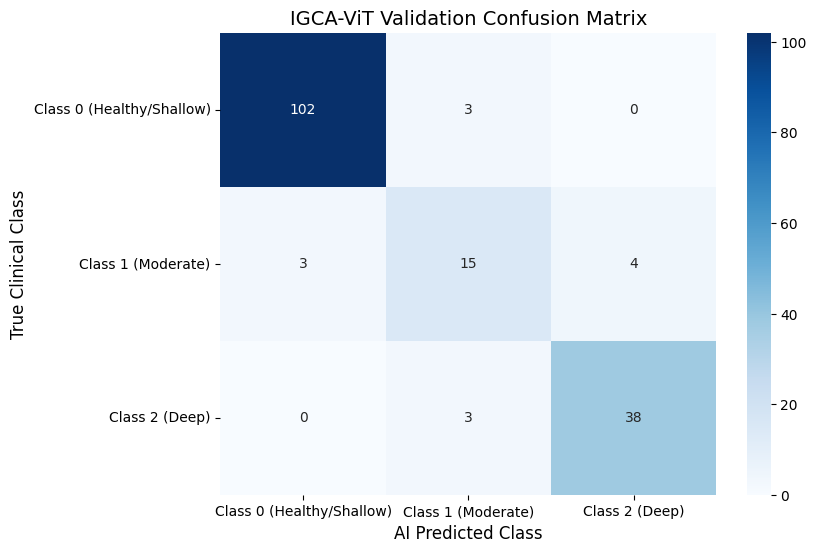

In [ ]:
# ==============================================================================
# MASTER THESIS PIPELINE: IGCA-ViT for OSCC Depth of Invasion
# Author: Rajesh
# Architecture: Interface-Guided Cross-Attention Vision Transformer (Transfer Learning)
# Techniques: Joint Augmentation, Weighted Random Sampling, Weighted Cross-Entropy
# ==============================================================================

import os
import cv2
import random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from sklearn.metrics import classification_report, confusion_matrix

# ==============================================================================
# PART 5: FINAL EVALUATION ON BEST WEIGHTS
# ==============================================================================
print("\n--- Running Final Evaluation on Best Model ---")
eval_model = IGCA_ViT_Transfer(num_classes=3).to(device)
eval_model.load_state_dict(torch.load('/content/drive/MyDrive/MTech_Thesis_Dataset/Without_weight_loss_IGCA_ViT_Best_Weights.pth', map_location=device))
eval_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, bulk_masks, edge_masks, labels in val_loader:
        imgs, bulk_masks, edge_masks = imgs.to(device), bulk_masks.to(device), edge_masks.to(device)
        outputs = eval_model(imgs, bulk_masks, edge_masks)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n=== CLASSIFICATION REPORT ===")
target_names = ['Class 0 (Healthy/Shallow)', 'Class 1 (Moderate)', 'Class 2 (Deep)']
print(classification_report(all_labels, all_preds, target_names=target_names))

print("\n=== GENERATING CONFUSION MATRIX ===")
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('IGCA-ViT Validation Confusion Matrix', fontsize=14)
plt.ylabel('True Clinical Class', fontsize=12)
plt.xlabel('AI Predicted Class', fontsize=12)
plt.show()